In [12]:
# Step 1: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


print("Saravanan 24BAD105")

# Step 2: Upload ratings.csv and movies.csv
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

print("Ratings Shape:", ratings.shape)
print("Movies Shape:", movies.shape)



ratings.head()

Saravanan 24BAD105
Ratings Shape: (105339, 4)
Movies Shape: (10329, 3)


,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


In [2]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:

# Step 3: Create User-Item Matrix

ratings = ratings[['userId','movieId','rating']]

train_data, test_data = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

user_item_matrix = train_data.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

print("Matrix Shape:", user_item_matrix.shape)
     


# Step 4: Handle Missing Values

matrix_filled = user_item_matrix.fillna(0)

matrix_filled.head()

Matrix Shape: (668, 9588)


movieId,1,2,3,4,5,6,7,8,9,10,...,143882,144656,144976,146344,146656,146684,146878,148238,148626,149532
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:

# Step 5: Apply NMF

n_components = 20   # latent features

nmf_model = NMF(
    n_components=n_components,
    init='random',
    random_state=42,
    max_iter=200
)

# Factorization
user_features = nmf_model.fit_transform(
    matrix_filled
)

item_features = nmf_model.components_

print("User Feature Matrix Shape:",
      user_features.shape)

print("Item Feature Matrix Shape:",
      item_features.shape)

User Feature Matrix Shape: (668, 20)
Item Feature Matrix Shape: (20, 9588)


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [5]:

# Step 5: Apply NMF

n_components = 20   # latent features

nmf_model = NMF(
    n_components=n_components,
    init='random',
    random_state=42,
    max_iter=200
)

# Factorization
user_features = nmf_model.fit_transform(
    matrix_filled
)

item_features = nmf_model.components_

print("User Feature Matrix Shape:",
      user_features.shape)

print("Item Feature Matrix Shape:",
      item_features.shape)

User Feature Matrix Shape: (668, 20)
Item Feature Matrix Shape: (20, 9588)


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [6]:
# Step 6: Reconstruct Matrix

reconstructed_matrix = np.dot(
    user_features,
    item_features
)

reconstructed_df = pd.DataFrame(
    reconstructed_matrix,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

reconstructed_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,143882,144656,144976,146344,146656,146684,146878,148238,148626,149532
userId,,,,,,,,,,,,,,,,,,,,,
1,1.817785,0.487703,0.264959,0.021710,0.198009,0.731845,0.177487,0.032309,0.112848,0.978714,...,0.0,0.0,0.0,0.0,0.000000,0.028024,0.017515,0.0,0.000244,0.0
2,1.842656,0.185936,1.225524,0.024679,1.092423,1.706158,0.909716,0.080099,0.489073,0.019619,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0
3,0.495293,0.554469,0.252935,0.062461,0.118558,0.473361,0.130652,0.055944,0.083535,1.634398,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0
4,0.180986,0.080759,0.000707,0.103294,0.072369,0.151273,0.051959,0.001359,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0
5,0.522790,0.149727,0.095166,0.004624,0.099891,0.177929,0.135009,0.012029,0.034351,0.159107,...,0.0,0.0,0.0,0.0,0.019032,0.001596,0.000997,0.0,0.005962,0.0


In [7]:
# Step 7: Predict Missing Ratings

preds = []
actuals = []

for row in test_data.itertuples():

    user = row.userId
    movie = row.movieId

    if user in reconstructed_df.index \
       and movie in reconstructed_df.columns:

        pred = reconstructed_df.loc[user, movie]

        preds.append(pred)

        actuals.append(row.rating)

# Calculate RMSE

rmse = np.sqrt(
    mean_squared_error(actuals, preds)
)

print("RMSE:", rmse)

RMSE: 3.0763491846080604


In [8]:

# Step 8: Precision@K and Recall@K

def precision_recall_at_k(
        reconstructed_df,
        user_item_matrix,
        k=10,
        threshold=3.5):

    precisions = []
    recalls = []

    for user in reconstructed_df.index:

        user_true = user_item_matrix.loc[user]

        user_pred = reconstructed_df.loc[user]

        already_rated = user_true.dropna().index

        recommendations = user_pred.drop(
            already_rated
        )

        top_k = recommendations.sort_values(
            ascending=False
        ).head(k)

        relevant_items = user_true[
            user_true >= threshold
        ].index

        recommended_items = top_k.index

        true_positives = len(
            set(recommended_items)
            &
            set(relevant_items)
        )

        precision = true_positives / k

        recall = true_positives / \
            max(len(relevant_items),1)

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), \
           np.mean(recalls)


precision_k, recall_k = \
    precision_recall_at_k(
        reconstructed_df,
        user_item_matrix,
        k=10
    )

print("Precision@10:", precision_k)
print("Recall@10   :", recall_k)

Precision@10: 0.0
Recall@10   : 0.0


In [9]:
# Step 9: Top-N Recommendations

sample_user = reconstructed_df.index[0]

user_ratings = reconstructed_df.loc[
    sample_user
]

already_rated = user_item_matrix.loc[
    sample_user
].dropna().index

recommendations = user_ratings.drop(
    already_rated
)

top_n = recommendations.sort_values(
    ascending=False
).head(10)

top_movies = movies[
    movies['movieId'].isin(top_n.index)
]

print("\nTop 10 Recommended Movies:")

print(top_movies[['movieId','title']])


Top 10 Recommended Movies:
      movieId                                              title
0           1                                   Toy Story (1995)
258       293  Léon: The Professional (a.k.a. The Professiona...
471       527                            Schindler's List (1993)
522       589                  Terminator 2: Judgment Day (1991)
695       858                              Godfather, The (1972)
975      1214                                       Alien (1979)
999      1240                             Terminator, The (1984)
1029     1270                          Back to the Future (1985)
7669    58559                            Dark Knight, The (2008)
8629    79132                                   Inception (2010)


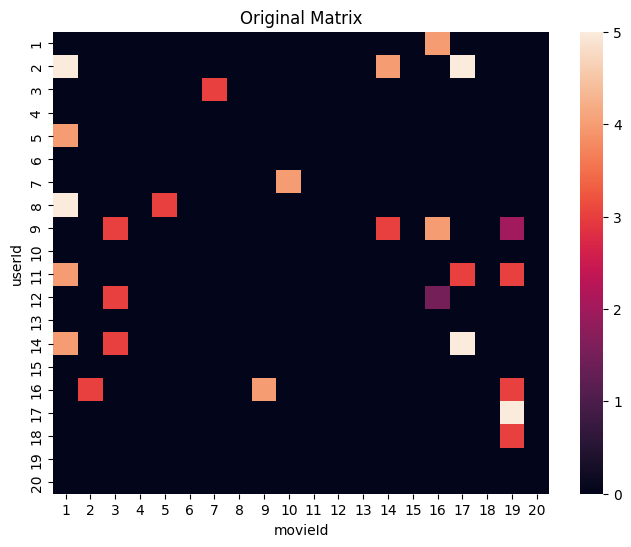

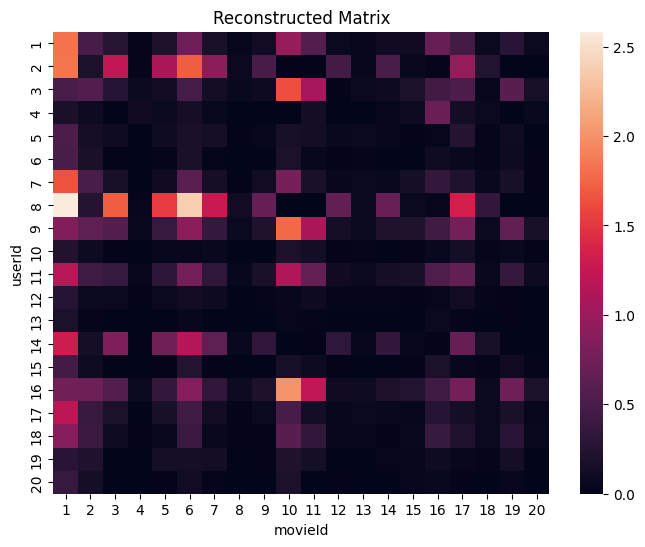

In [10]:

# Visualization 2: Reconstruction Comparison

sample_original = matrix_filled.iloc[:20,:20]

sample_reconstructed = \
    reconstructed_df.iloc[:20,:20]

plt.figure(figsize=(8,6))

sns.heatmap(sample_original)

plt.title("Original Matrix")

plt.show()

plt.figure(figsize=(8,6))

sns.heatmap(sample_reconstructed)

plt.title("Reconstructed Matrix")

plt.show()

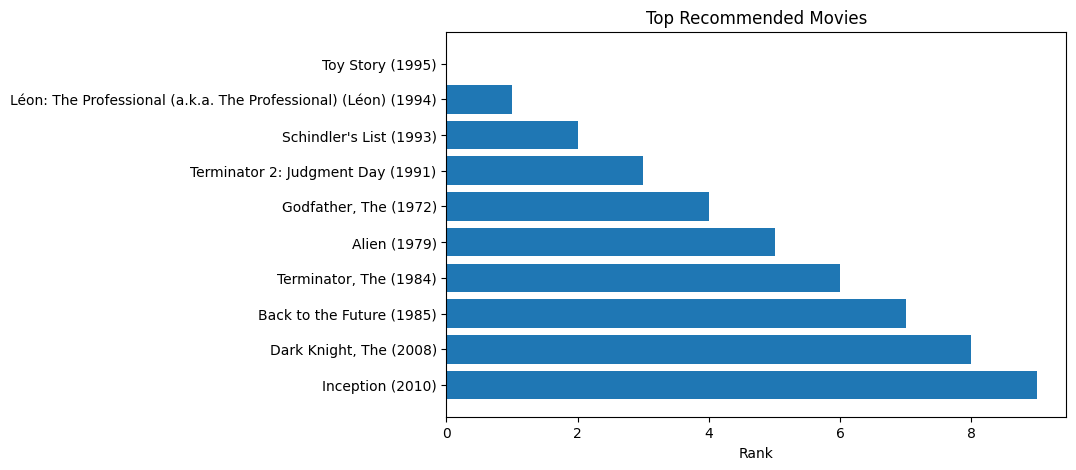

In [11]:

# Visualization 3: Recommendation Ranking

titles = top_movies['title']

plt.figure(figsize=(8,5))

plt.barh(
    titles,
    range(len(titles))
)

plt.xlabel("Rank")

plt.title("Top Recommended Movies")

plt.gca().invert_yaxis()

plt.show()